In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('housing.csv' , usecols=['GarageQual' , 'FireplaceQu' , 'SalePrice'])

In [8]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [9]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'Number of houses')

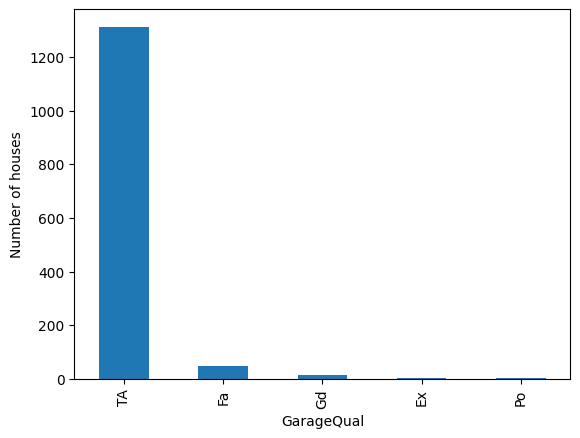

In [13]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

In [14]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

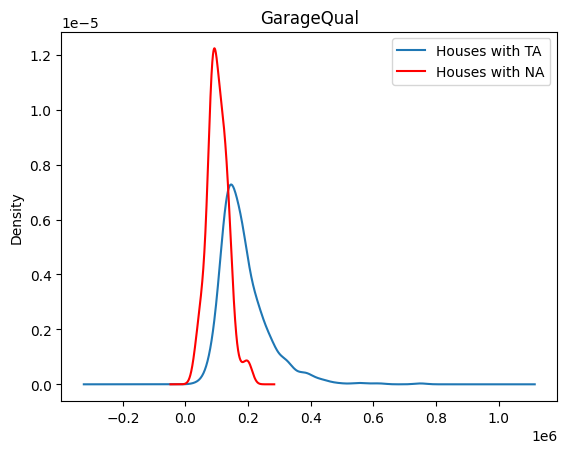

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde' , ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde' , ax=ax , color='red')
lines , labels = ax.get_legend_handles_labels()
labels = ['Houses with TA' , 'Houses with NA']
ax.legend(lines, labels ,loc='best')
plt.title('GarageQual')

In [16]:
df[df['GarageQual'] == 'TA']['SalePrice']

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1311, dtype: int64

In [17]:
df['GarageQual'].fillna('TA' , inplace=True)

In [20]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']

<Axes: xlabel='GarageQual'>

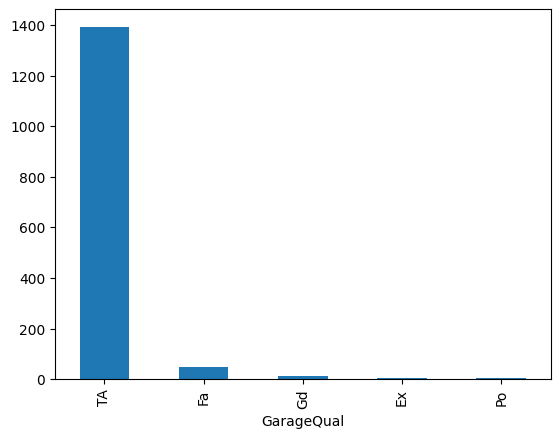

In [18]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

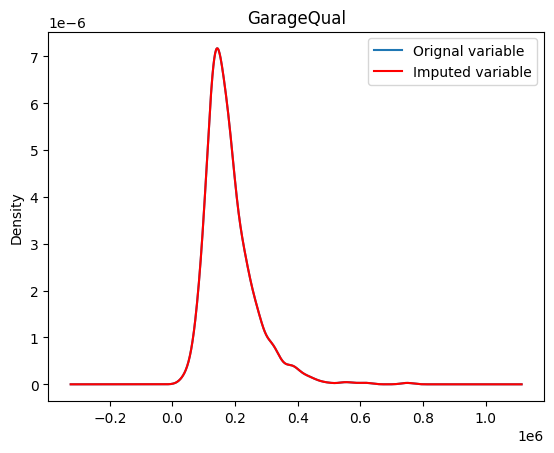

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111)
temp.plot(kind = 'kde' , ax=ax)
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')
lines , labels=ax.get_legend_handles_labels()
labels = ['Orignal variable' , 'Imputed variable']
ax.legend(lines , labels , loc='best')
plt.title('GarageQual')

In [22]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(df.drop(columns = ['SalePrice']) , df['SalePrice'] , test_size=0.2)

In [23]:
from sklearn.impute import SimpleImputer

In [27]:
imputer = SimpleImputer(strategy = 'constant' , fill_value = 'Missing')

In [28]:
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [29]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)